In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, RocCurveDisplay, roc_auc_score
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

RANDOM_STATE = 42


In [3]:
# Titanic de OpenML (versión limpia, columnas estándar)
titanic = fetch_openml("titanic", version=1, as_frame=True)
df = titanic.frame.copy()

# Selección y limpieza mínima
cols = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
df = df[cols + ["survived"]].dropna()

X = df[cols]
y = df["survived"].astype(int)

num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["pclass", "sex", "embarked"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

X_train.shape, X_test.shape, y_train.mean(), y_test.mean()


((834, 7),
 (209, 7),
 np.float64(0.407673860911271),
 np.float64(0.40669856459330145))

In [4]:
pre = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

rf = RandomForestClassifier(random_state=RANDOM_STATE)
gb = GradientBoostingClassifier(random_state=RANDOM_STATE)

pipe_rf = Pipeline([("pre", pre), ("clf", rf)])
pipe_gb = Pipeline([("pre", pre), ("clf", gb)])


In [5]:
rf_grid = {
    "clf__n_estimators": [150, 300],
    "clf__max_depth": [None, 5, 8]
}

gb_grid = {
    "clf__n_estimators": [100, 200],
    "clf__learning_rate": [0.05, 0.1],
    "clf__max_depth": [2, 3]
}

gs_rf = GridSearchCV(pipe_rf, rf_grid, scoring="f1", cv=5, n_jobs=-1)
gs_gb = GridSearchCV(pipe_gb, gb_grid, scoring="f1", cv=5, n_jobs=-1)

gs_rf.fit(X_train, y_train)
gs_gb.fit(X_train, y_train)

print("RF best:", gs_rf.best_params_, "f1_cv:", round(gs_rf.best_score_, 3))
print("GB best:", gs_gb.best_params_, "f1_cv:", round(gs_gb.best_score_, 3))


RF best: {'clf__max_depth': 5, 'clf__n_estimators': 150} f1_cv: 0.733
GB best: {'clf__learning_rate': 0.05, 'clf__max_depth': 2, 'clf__n_estimators': 100} f1_cv: 0.733



== RF ==
              precision    recall  f1-score   support

           0      0.795     0.935     0.859       124
           1      0.873     0.647     0.743        85

    accuracy                          0.818       209
   macro avg      0.834     0.791     0.801       209
weighted avg      0.826     0.818     0.812       209

AUC: 0.852


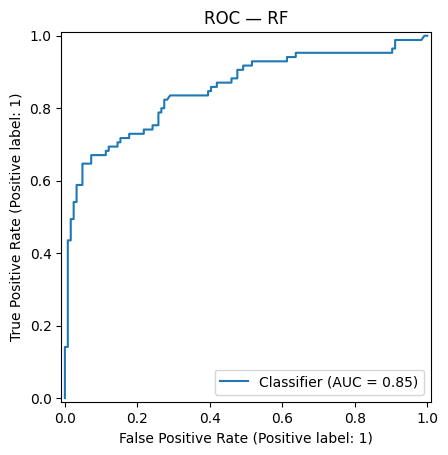


== GB ==
              precision    recall  f1-score   support

           0      0.785     0.944     0.857       124
           1      0.883     0.624     0.731        85

    accuracy                          0.813       209
   macro avg      0.834     0.784     0.794       209
weighted avg      0.825     0.813     0.806       209

AUC: 0.853


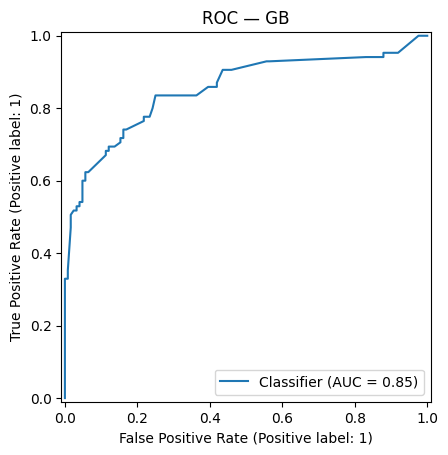

In [6]:
for name, model in [("RF", gs_rf), ("GB", gs_gb)]:
    y_pred = model.predict(X_test)
    print(f"\n== {name} ==")
    print(classification_report(y_test, y_pred, digits=3))

    # ROC
    proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, proba)
    print("AUC:", round(auc, 3))
    RocCurveDisplay.from_predictions(y_test, proba)
    plt.title(f"ROC — {name}")
    plt.show()


In [7]:
best = gs_rf if gs_rf.best_score_ >= gs_gb.best_score_ else gs_gb
print("Usando para explicación:", "RF" if best is gs_rf else "GB")

r = permutation_importance(best, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE)
imp = pd.DataFrame({"feature": X_test.columns, "importance": r.importances_mean}).sort_values("importance", ascending=False)
imp


Usando para explicación: GB


,feature,importance
1,sex,0.280491
2,age,0.073248
0,pclass,0.058879
3,sibsp,0.029445
5,fare,0.007924
6,embarked,0.006327
4,parch,0.000000


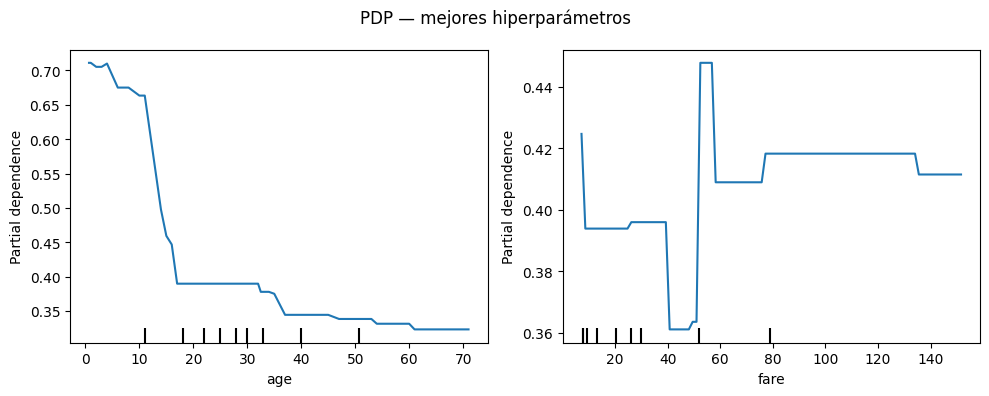

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))
PartialDependenceDisplay.from_estimator(best, X_test, features=["age"], ax=ax[0])
PartialDependenceDisplay.from_estimator(best, X_test, features=["fare"], ax=ax[1])
plt.suptitle("PDP — mejores hiperparámetros")
plt.tight_layout()
plt.show()
